# Diagonal integration: [multiple RNA, multiple ATAC], every method

This notebook runs every method that has a variant for diagonal [multiple RNA, multiple ATAC] on `D37mini`: GLUE, iNMF, online_iNMF and scJoint. The [tutorial](https://dsichang.github.io/scMultiBench/tutorials/diagonal_multi/) explains each step and runs iNMF and online_iNMF only.

Methods run on Linux. The environments are 3 envs, 4.8 GB to download on a CPU host, 8.4 GB on a GPU host.

## 1. Install

This cell installs `multibench-sc`. It keeps the numpy and pandas that are already installed, so Colab needs no restart.

<details>
<summary>Details</summary>

On Colab, choose a GPU runtime before you run the notebook: Runtime -> Change runtime type -> T4 GPU. On a CPU runtime, an environment that has a smaller CPU build gets that build, and training methods run slower.

</details>

In [1]:
import numpy, pandas
%pip install -q multibench-sc numpy=={numpy.__version__} pandas=={pandas.__version__}

Note: you may need to restart the kernel to use updated packages.


## 2. Download the data and the environments

In [2]:
import pandas as pd
import multibench as mtb

mtb.data.fetch("D37mini")

PosixPath('/tmp/mbverify/home/.cache/multibench/data')

In [3]:
METHODS = ["GLUE", "iNMF", "online_iNMF", "scJoint"]
envs = mtb.env.install(METHODS, dry_run=False)
pd.DataFrame(envs)[["env", "methods", "state"]]

,env,methods,state
0,scmb_r,"[iNMF, online_iNMF]",have
1,glue,[GLUE],have
2,scmb_scjoint,[scJoint],have


## 3. Run the methods

In [4]:
res = mtb.run_all("D37mini", "diagonal", methods=METHODS,
                  out_dir="out/D37mini_all")
res.summary

[run_all] 4 more rows need files this folder does not have. mtb.scan shows them.


[run_all] GLUE (diagonal/D37mini) ...


[run_all]   GLUE reads the GENCODE v43 human annotation (gencode.v43.chr_patch_hapl_scaff.annotation.gtf.gz, 53 MB) from <repo_path>/tools_scripts/GLUE/.


[run_all]   -> CHAIN_OK (566.8s) ARI 0.621


[run_all] iNMF (diagonal/D37mini) ...


...

[run_all] online_iNMF (diagonal/D37mini) ...


[run_all]   -> CHAIN_OK (8.5s) ARI 0.495


[run_all] scJoint (diagonal/D37mini) ...


[run_all]   -> CHAIN_OK (43.0s) ARI 0.790


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,...,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note,caveat,reason
0,GLUE,CHAIN_OK,566.8,embedding,"[6000, 50]",0,rna_cty1.csv+rna_cty2.csv+rna_cty3.csv+atac_ct...,0.0,file_of_origin,6,...,0.5784,0.5650,0.5763,0.9682,0.9190,0.8660,0.7108,None,GLUE reads the GENCODE v43 human annotation (g...,
1,iNMF,CHAIN_OK,15.7,embedding,"[6000, 20]",0,rna_cty1.csv+rna_cty2.csv+rna_cty3.csv+atac_ct...,0.0,file_of_origin,6,...,0.5357,0.5605,0.5696,0.9696,0.9020,0.7801,0.6074,None,,
2,online_iNMF,CHAIN_OK,8.5,embedding,"[6000, 20]",0,rna_cty1.csv+rna_cty2.csv+rna_cty3.csv+atac_ct...,0.0,file_of_origin,6,...,0.5071,0.5400,0.5100,0.9408,0.8754,0.8435,0.6265,None,,
3,scJoint,CHAIN_OK,43.0,embedding,"[6000, 64]",21,rna_cty1.csv+rna_cty2.csv+rna_cty3.csv+atac_ct...,0.0,file_of_origin,6,...,0.5758,0.5631,0.7661,0.9915,0.9278,0.9444,0.5487,None,,


## 4. Plot

`res.plot()` draws the scores as a bubble table. Circle size shows the rank within a column, and bigger is better. The fill compares a value with the other rows in the same column.

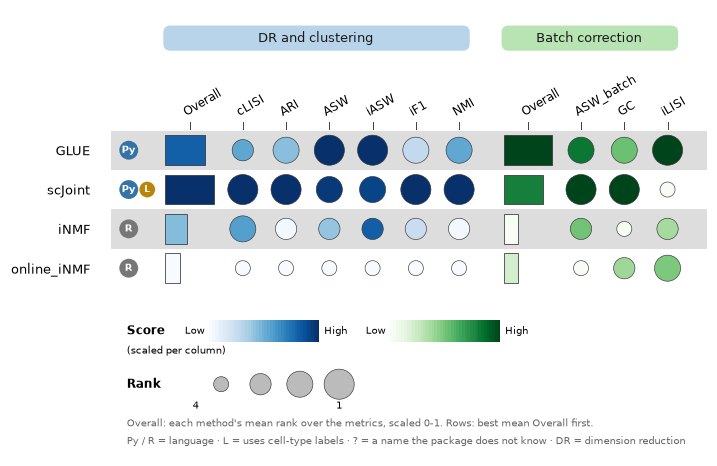

In [5]:
res.plot()